In [8]:
import pandas as pd
import numpy as np

# -------------------------------
# Load Data
# -------------------------------

df = pd.read_excel(
    "../data/processed/Combined_Data.xlsx",
    sheet_name="Support Tickets"
)

# -------------------------------
# Convert Date Columns
# -------------------------------

df["Created Time (Ticket)"] = pd.to_datetime(
    df["Created Time (Ticket)"],
    errors="coerce"
)

df["Ticket Closed Time"] = pd.to_datetime(
    df["Ticket Closed Time"],
    errors="coerce"
)

# -------------------------------
# Resolution Time
# -------------------------------

df["Resolution Hours"] = (
    df["Ticket Closed Time"] -
    df["Created Time (Ticket)"]
).dt.total_seconds() / 3600

# -------------------------------
# Ticket Age
# -------------------------------

today = pd.Timestamp.today()

df["Ticket Age (Days)"] = (
    today -
    df["Created Time (Ticket)"]
).dt.days

# -------------------------------
# Closed Ticket Flag
# -------------------------------

df["Ticket Closed"] = np.where(
    df["Ticket Closed Time"].notna(),
    1,
    0
)

# -------------------------------
# Status Score
# -------------------------------

status_score = {
    "Closed":5,
    "Resolved":4,
    "In Progress":3,
    "Open":2,
    "Pending":1
}

df["Status Score"] = (
    df["Status (Ticket)"]
    .map(status_score)
    .fillna(0)
)

# -------------------------------
# Project Phase Score
# -------------------------------

phase_score = {
    "Completed":5,
    "Deployment":4,
    "Testing":3,
    "Development":2,
    "Planning":1
}

df["Phase Score"] = (
    df["Project Phase"]
    .map(phase_score)
    .fillna(0)
)

# -------------------------------
# Resolution Speed Tier
# -------------------------------

df["Resolution Tier"] = pd.cut(
    df["Resolution Hours"],
    bins=[0,24,72,float("inf")],
    labels=[
        "Fast",
        "Medium",
        "Slow"
    ]
)

# -------------------------------
# Resolution Quartile
# -------------------------------

df["Resolution Quartile"] = pd.qcut(
    df["Resolution Hours"],
    q=4,
    labels=[
        "Q1",
        "Q2",
        "Q3",
        "Q4"
    ],
    duplicates="drop"
)

# -------------------------------
# Convert First Response Time
# -------------------------------

df["First Response Time"] = pd.to_datetime(
    df["First Response Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

# -------------------------------
# First Response Hours
# -------------------------------

df["First Response Hours"] = (
    df["First Response Time"] -
    df["Created Time (Ticket)"]
).dt.total_seconds() / 3600

# -------------------------------
# Response Tier
# -------------------------------

df["Response Tier"] = pd.cut(
    df["First Response Hours"],
    bins=[0,2,8,float("inf")],
    labels=[
        "Excellent",
        "Good",
        "Poor"
    ]
)

# -------------------------------
# Ticket Health Score
# -------------------------------

resolution_score = (
    5 -
    pd.qcut(
        df["Resolution Hours"],
        q=5,
        labels=[1,2,3,4,5],
        duplicates="drop"
    ).astype(float)
)

response_score = (
    5 -
    pd.qcut(
        df["First Response Hours"],
        q=5,
        labels=[1,2,3,4,5],
        duplicates="drop"
    ).astype(float)
)

df["Ticket Health Score"] = (
    resolution_score.fillna(0)
    + response_score.fillna(0)
    + df["Status Score"]
    + df["Phase Score"]
)

# -------------------------------
# Validation
# -------------------------------

print("="*60)
print("Feature Engineering Validation")
print("="*60)

print("\nResolution Tier Distribution")
print(df["Resolution Tier"].value_counts())

print("\nResponse Tier Distribution")
print(df["Response Tier"].value_counts())

print("\nResolution Quartiles")
print(df["Resolution Quartile"].value_counts())

print("\nTicket Health Score")

print(df["Ticket Health Score"].describe())

print("\nMissing Values")

print(
    df[
        [
            "Resolution Tier",
            "Resolution Quartile",
            "Ticket Health Score"
        ]
    ].isna().sum()
)

# -------------------------------
# Save
# -------------------------------

df.to_excel(
    "../output/Feature_Engineered_Data.xlsx",
    index=False
)

print("\nFeature Engineered Data Saved Successfully!")

Feature Engineering Validation

Resolution Tier Distribution
Resolution Tier
Fast      309
Medium    135
Slow       17
Name: count, dtype: int64

Response Tier Distribution
Response Tier
Excellent    190
Poor          89
Good          56
Name: count, dtype: int64

Resolution Quartiles
Resolution Quartile
Q1    117
Q2    117
Q3    117
Q4    117
Name: count, dtype: int64

Ticket Health Score
count    476.000000
mean       7.111345
std        3.273208
min        0.000000
25%        4.000000
50%        7.000000
75%       10.000000
max       13.000000
Name: Ticket Health Score, dtype: float64

Missing Values
Resolution Tier        15
Resolution Quartile     8
Ticket Health Score     0
dtype: int64

Feature Engineered Data Saved Successfully!


C:\Users\NallapureddyRishitha\AppData\Local\Temp\ipykernel_5352\1845159030.py:17: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Created Time (Ticket)"] = pd.to_datetime(
C:\Users\NallapureddyRishitha\AppData\Local\Temp\ipykernel_5352\1845159030.py:22: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Ticket Closed Time"] = pd.to_datetime(


In [10]:
print("=" * 60)
print("New Feature Preview")
print("=" * 60)

print(df[[
    "Resolution Hours",
    "Ticket Age (Days)",
    "First Response Hours",
    "Resolution Tier",
    "Response Tier",
    "Ticket Health Score"
]].head(10))

New Feature Preview
   Resolution Hours  Ticket Age (Days)  First Response Hours Resolution Tier  \
0         17.916667               1909              7.700000            Fast   
1          1.183333               1908                   NaN            Fast   
2         36.383333               1908              6.466667          Medium   
3         17.933333               1909             13.616667            Fast   
4          8.366667               1908              0.066667            Fast   
5         47.650000               1908              7.666667          Medium   
6          0.016667               1909                   NaN            Fast   
7        113.866667               1909             12.866667            Slow   
8         10.866667               1909              8.100000            Fast   
9         92.066667               1909              9.650000            Slow   

  Response Tier  Ticket Health Score  
0          Good                  8.0  
1           NaN      

In [11]:
from pathlib import Path

charts_folder = Path("../charts")
charts_folder.mkdir(exist_ok=True)

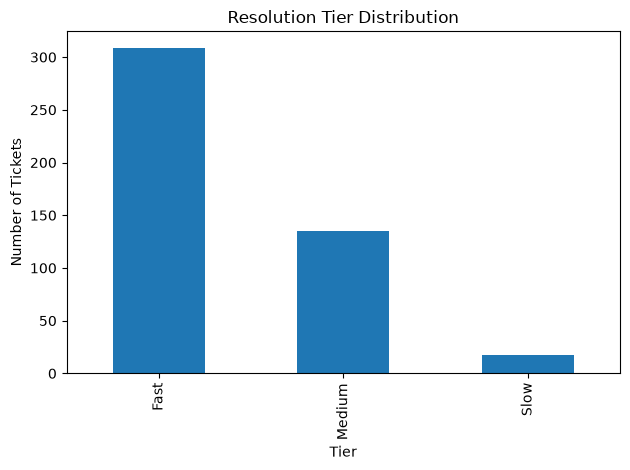

In [12]:
import matplotlib.pyplot as plt

df["Resolution Tier"].value_counts().plot(kind="bar")

plt.title("Resolution Tier Distribution")
plt.xlabel("Tier")
plt.ylabel("Number of Tickets")

plt.tight_layout()

plt.savefig("../charts/resolution_tier.png")

plt.show()

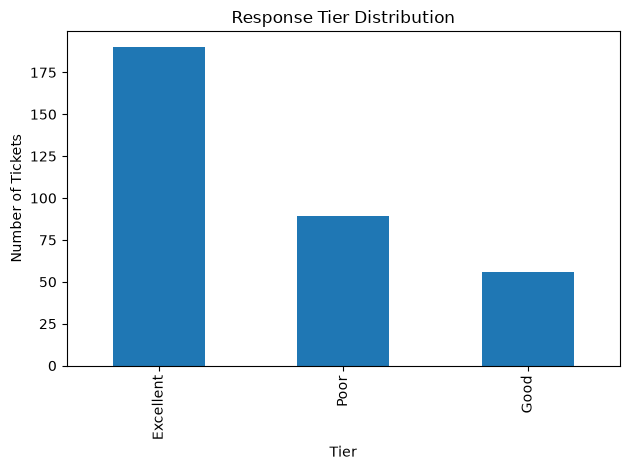

In [13]:
df["Response Tier"].value_counts().plot(kind="bar")

plt.title("Response Tier Distribution")
plt.xlabel("Tier")
plt.ylabel("Number of Tickets")

plt.tight_layout()

plt.savefig("../charts/response_tier.png")

plt.show()

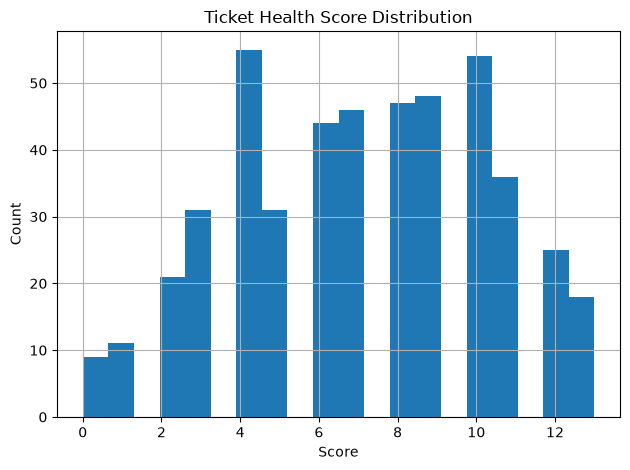

In [14]:
df["Ticket Health Score"].hist(bins=20)

plt.title("Ticket Health Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../charts/ticket_health_score.png")

plt.show()

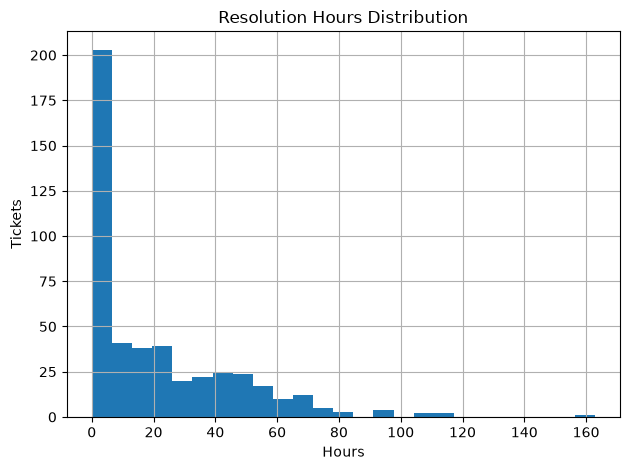

In [15]:
df["Resolution Hours"].dropna().hist(bins=25)

plt.title("Resolution Hours Distribution")
plt.xlabel("Hours")
plt.ylabel("Tickets")

plt.tight_layout()

plt.savefig("../charts/resolution_hours.png")

plt.show()

In [16]:
df.to_excel(
    "../output/Feature_Engineered_Data.xlsx",
    index=False
)

print("Feature Engineered Data Saved")

Feature Engineered Data Saved
